ECB Speeches

In [7]:
from pathlib import Path
import pandas as pd
import fredapi
from fredapi import Fred

Importing Fred Data

Inflation

In [8]:
# Api Key
fred_api_key = Fred(api_key="88a8844ca93e8780390f1ea6641677f3")
# Start Dates
start_date = "2000-01-01"
# End Dates
end_date = "2026-01-01"
inflation_data_ids = {"US_Annual_CPI": "FPCPITOTLZGUSA", "Ten_Yr_US_Brk_even": "T10YIEM"}
# Making the data frame
raw_monthly_inflation_data = pd.concat({name: fred_api_key.get_series(sid, observation_start=start_date, observation_end=end_date)
    for name, sid in inflation_data_ids.items()},
    axis=1
)
# Converting the raw monthly data into daily data and keeping the time frame consistent with the rest of the data
daily_inflation_data = raw_monthly_inflation_data.resample('ME').ffill()
daily_inflation_data

/var/folders/k1/mhyzg0w15gb04d0x6q7gdp2w0000gn/T/ipykernel_46538/1080017854.py:9: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  raw_monthly_inflation_data = pd.concat({name: fred_api_key.get_series(sid, observation_start=start_date, observation_end=end_date)


,US_Annual_CPI,Ten_Yr_US_Brk_even
2000-01-31,3.376857,NaN
2000-02-29,3.376857,NaN
2000-03-31,3.376857,NaN
2000-04-30,3.376857,NaN
2000-05-31,3.376857,NaN
...,...,...
2025-09-30,NaN,2.37
2025-10-31,NaN,2.31
2025-11-30,NaN,2.27
2025-12-31,NaN,2.24


Unemployment

In [9]:
# Api Key
fred_api_key = Fred(api_key="88a8844ca93e8780390f1ea6641677f3")
# Start Dates
start_date = "2000-01-01"
# End Dates
end_date = "2026-01-01"
emply_data_ids = {"US_Unemploy": "UNRATE",}
# Making the data frame
raw_monthly_unemploy_data = pd.concat({name: fred_api_key.get_series(sid, observation_start=start_date, observation_end=end_date)
    for name, sid in emply_data_ids.items()},
    axis=1
)
# Converting the raw monthly data into daily data and keeping the time frame consistent with the rest of the data
daily_unemploy_data = raw_monthly_unemploy_data.resample('ME').ffill()
daily_unemploy_data

,US_Unemploy
2000-01-31,4.0
2000-02-29,4.1
2000-03-31,4.0
2000-04-30,3.8
2000-05-31,4.0
...,...
2025-09-30,4.4
2025-10-31,NaN
2025-11-30,4.5
2025-12-31,4.4


Merged on Date Hawkish, Dovish Dataframe

In [10]:
fomc_announcment_path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/FOMC STATEMENTS")
fomc_pressconf_path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/Press Conferences")
fomc_speech_path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/Speeches/Annotated with Shah Merge/")

fomc_announcment = pd.read_excel(fomc_announcment_path/ "fomc_statements_train_1000.xls")
fomc_pressconf = pd.read_excel(fomc_pressconf_path / "presconf_to_annotate.xlsx")
fomc_speech = pd.read_excel(fomc_speech_path / "lab-manual-sp-train-5768-augmented.xlsx")



In [11]:
fomc_announcment.head(10)

,id,raw_text,doc_type,clean_text,sentence,label,date,exact_match
0,2011,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,"In these circumstances, and against the backgr...",H,2000-02-02,False
1,2009,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,Although core measures of prices are rising sl...,MH,2000-03-21,False
2,2006,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,Against the background of its long-term goals ...,H,2000-05-16,False
3,2008,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,Recent data suggest that the expansion of aggr...,N,2000-05-16,False
4,2004,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,The data also have indicated that more rapid a...,N,2000-06-28,False
5,1997,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,Recent data have indicated that the expansion ...,H,2000-08-22,False
6,1999,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,"Moreover, the increase in energy prices, thoug...",MH,2000-08-22,False
7,1996,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,The Federal Open Market Committee at its meeti...,H,2000-08-22,True
8,1995,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,"Nonetheless, to date the easing of demand pres...",H,2000-10-03,False
9,1993,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,"The Committee, accordingly, continues to see a...",MD,2000-10-03,False


In [12]:
fomc_pressconf.head(10)

,date,file,speaker,sentence,label,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,These projections are conditional on each part...,N,NaN,NaN,N,507.0
1,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,"Perhaps most important, attempting to maintain...",D,NaN,NaN,H,248.0
2,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,"Indeed, most central banks around the world ai...",N,NaN,NaN,D,243.0
3,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,"For example, the unemployment rate moved down ...",H,NaN,NaN,NaN,NaN
4,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,the markdown of growth in 2011 in particular r...,D,NaN,NaN,NaN,NaN
5,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,The outlook for above-trend growth is associat...,H,NaN,NaN,NaN,NaN
6,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,"At 8.8 percent, the current unemployment rate ...",D,NaN,NaN,NaN,NaN
7,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,The substantial ongoing slack in the labor mar...,D,NaN,NaN,NaN,NaN
8,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,"Importantly, however, the Committee’s outlook ...",H,NaN,NaN,NaN,NaN
9,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,The Committee remains confident that it has th...,N,NaN,NaN,NaN,NaN


In [13]:
fomc_speech.head(10)

,sentence,year,label,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,"Moreover, we should recognize that these disin...",2021,D,NaN,N,520.0
1,There are a variety of versions of this basic ...,2004,N,NaN,D,201.0
2,"Of the 1,700 Washington employees, roughly 250...",2002,N,NaN,H,230.0
3,It is again useful to compare estimates of exp...,2020,H,NaN,NaN,NaN
4,Estimates by the staff of the Federal Reserve ...,1997,H,NaN,NaN,NaN
5,"As a case in point, the increase in the transp...",2017,N,NaN,NaN,NaN
6,That's why I said that flexibility is also an ...,2005,D,NaN,NaN,NaN
7,"Moreover, investing in EMEs has become more at...",2006,N,NaN,NaN,NaN
8,"Of course, the basic problem in tackling the i...",2002,H,NaN,NaN,NaN
9,"In the absence of legislation, going appreciab...",2022,D,NaN,NaN,NaN


Creating the Index

--- statements ---
columns: ['id', 'raw_text', 'doc_type', 'clean_text', 'sentence', 'label', 'date', 'exact_match']
     id                                           raw_text   doc_type  \
0  2011  The Federal Open Market Committee at its meeti...  statement   
1  2009  The Federal Open Market Committee at its meeti...  statement   
2  2006  The Federal Open Market Committee at its meeti...  statement   

                                          clean_text  \
0  The Federal Open Market Committee at its meeti...   
1  The Federal Open Market Committee at its meeti...   
2  The Federal Open Market Committee at its meeti...   

                                            sentence label       date  \
0  In these circumstances, and against the backgr...     H 2000-02-02   
1  Although core measures of prices are rising sl...    MH 2000-03-21   
2  Against the background of its long-term goals ...     H 2000-05-16   

   exact_match  
0        False  
1        False  
2        False  

---

/var/folders/k1/mhyzg0w15gb04d0x6q7gdp2w0000gn/T/ipykernel_46538/3629883377.py:65: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  macro   = pd.concat([raw_monthly_inflation_data, raw_monthly_unemploy_data], axis=1)


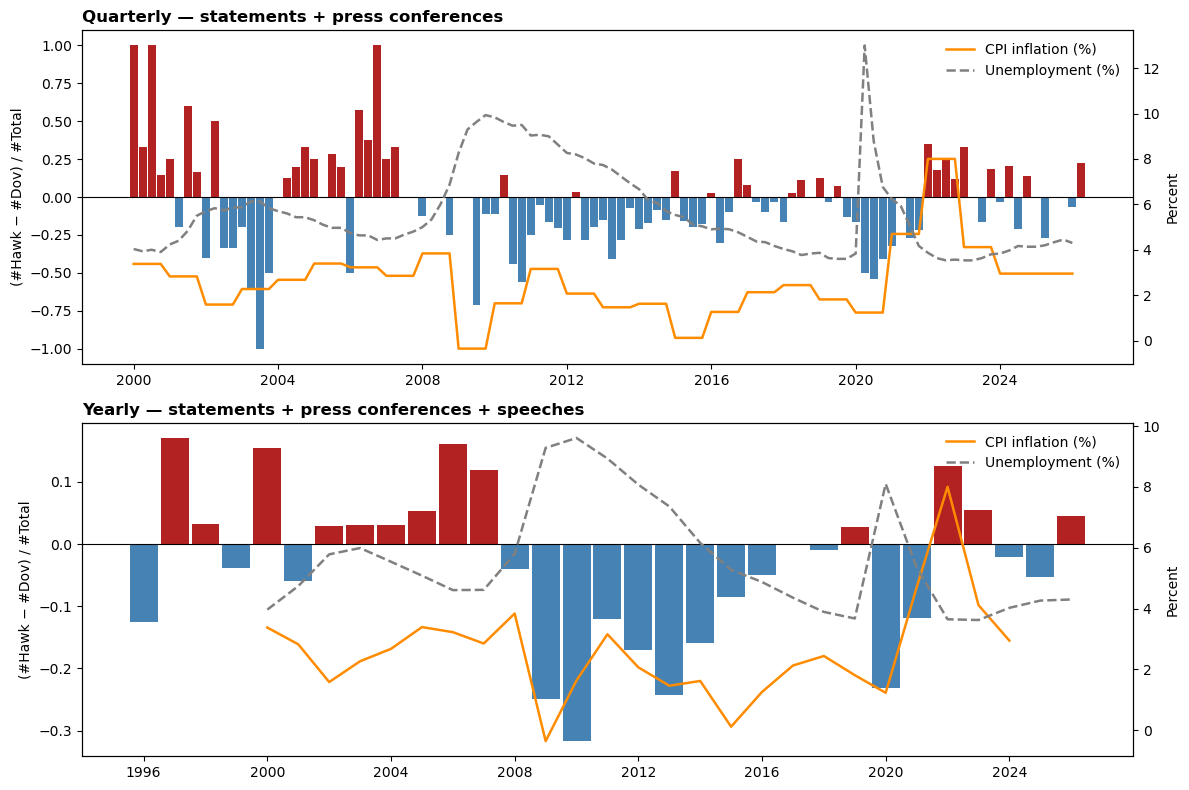

In [15]:

# %% [markdown]
# ### Hawkish–Dovish index
# Measure = (#Hawkish − #Dovish) / #Total
# Quarterly: statements + press conferences | Yearly: + speeches

# %%
import matplotlib.pyplot as plt

# --- edit these three lines if your column names differ ---
DATE_COL  = "date"    # date column in the statements & press conference files
YEAR_COL  = "year"    # the speeches file only has the year
LABEL_COL = "label"   # 0 = dovish, 1 = hawkish, 2 = neutral

def clean_label(x):
    code = str(x).strip().upper()
    if code in ("H", "MH"):   # hawkish, mildly hawkish
        return "hawkish"
    if code in ("D", "MD"):   # dovish, mildly dovish
        return "dovish"
    if code == "N":           # neutral
        return "neutral"
    return None

# %% [markdown]
# ### Diagnostic — run this if the counts above come back empty
# Paste the printed output back so the column names / label mapping can be fixed.

# %%
for name, df in [("statements", fomc_announcment), ("press conferences", fomc_pressconf), ("speeches", fomc_speech)]:
    print(f"--- {name} ---")
    print("columns:", list(df.columns))
    print(df.head(3))
    print()

# %%
stmts = pd.DataFrame({"date":  pd.to_datetime(fomc_announcment[DATE_COL], errors="coerce"),
                      "label": fomc_announcment[LABEL_COL].map(clean_label)}).dropna()

pressc = pd.DataFrame({"date":  pd.to_datetime(fomc_pressconf[DATE_COL], errors="coerce"),
                       "label": fomc_pressconf[LABEL_COL].map(clean_label)}).dropna()

speech = pd.DataFrame({"date":  pd.to_datetime(fomc_speech[YEAR_COL].astype(int).astype(str), format="%Y"),
                       "label": fomc_speech[LABEL_COL].map(clean_label)}).dropna()

# quick sanity check — if a file shows 0 sentences, its column names above are wrong
for name, df in [("statements", stmts), ("press conferences", pressc), ("speeches", speech)]:
    print(f"{name}: {len(df)} sentences  {df['label'].value_counts().to_dict()}")

# %%
def build_index(df, freq):
    """Measure per period. freq: 'Q' = quarterly, 'A' = yearly."""
    counts = df.groupby([pd.Grouper(key="date", freq=freq), "label"]).size().unstack(fill_value=0)
    index = (counts.get("hawkish", 0) - counts.get("dovish", 0)) / counts.sum(axis=1)
    return index

quarterly = build_index(pd.concat([stmts, pressc]), "QS")
yearly    = build_index(pd.concat([stmts, pressc, speech]), "YS")


# if either of these prints 0, go back and check the sanity-check counts above —
# it means the label mapping didn't match anything for one of the files
print("quarterly points:", quarterly.dropna().shape[0])
print("yearly points:", yearly.dropna().shape[0])

macro   = pd.concat([raw_monthly_inflation_data, raw_monthly_unemploy_data], axis=1)
macro_q = macro.resample("QS").mean().ffill()   # ffill because the CPI series is annual
macro_y = macro.resample("YS").mean()



# %%
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

panels = [(axes[0], quarterly, macro_q, 80,  "Quarterly — statements + press conferences"),
          (axes[1], yearly,    macro_y, 330, "Yearly — statements + press conferences + speeches")]

for ax, index, m, width, title in panels:
    ax.bar(index.index, index.values, width=width,
           color=["firebrick" if v >= 0 else "steelblue" for v in index])
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel("(#Hawk − #Dov) / #Total")

    axr = ax.twinx()
    axr.plot(m.index, m["US_Annual_CPI"], color="darkorange", lw=1.8, label="CPI inflation (%)")
    axr.plot(m.index, m["US_Unemploy"],  color="grey", ls="--", lw=1.8, label="Unemployment (%)")
    axr.set_ylabel("Percent")
    axr.legend(loc="upper right", frameon=False)

fig.tight_layout()
plt.show()

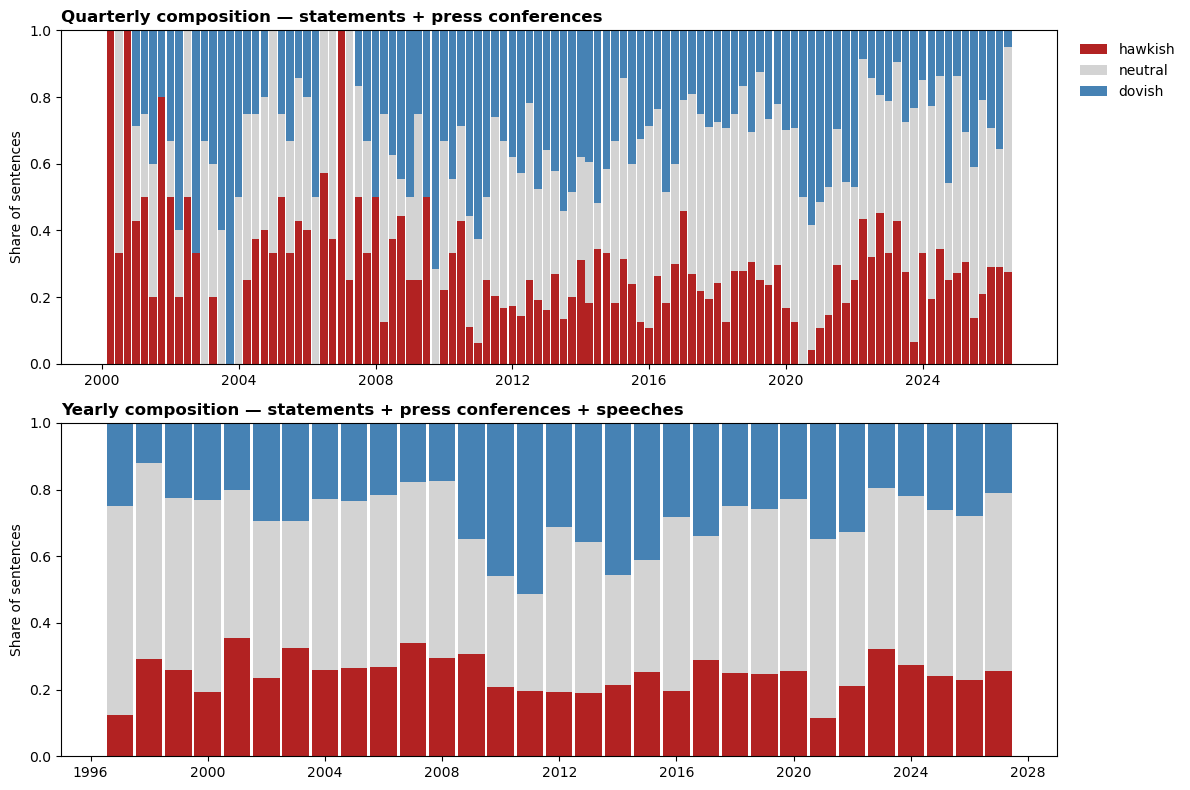

In [16]:
def build_composition(df, freq):
    counts = df.groupby([pd.Grouper(key="date", freq=freq), "label"]).size().unstack(fill_value=0)
    counts = counts.reindex(columns=["hawkish", "neutral", "dovish"], fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0)   # row-normalize to proportions
 
quarterly_comp = build_composition(pd.concat([stmts, pressc]), "QE")
yearly_comp    = build_composition(pd.concat([stmts, pressc, speech]), "YE")
 
# %%
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
colors = {"hawkish": "firebrick", "neutral": "lightgrey", "dovish": "steelblue"}
 
for ax, comp, width, title in [
    (axes[0], quarterly_comp, 80,  "Quarterly composition — statements + press conferences"),
    (axes[1], yearly_comp,    330, "Yearly composition — statements + press conferences + speeches"),
]:
    bottom = pd.Series(0.0, index=comp.index)
    for label in ["hawkish", "neutral", "dovish"]:
        ax.bar(comp.index, comp[label], width=width, bottom=bottom,
               color=colors[label], label=label)
        bottom += comp[label]
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel("Share of sentences")
    ax.set_ylim(0, 1)
 
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
fig.tight_layout()
plt.show()

ECB

In [19]:
# Paths 
ECB_announcment_path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/ECB/Annotated")
ECB_pressconf_path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/ECB/Annotated/")
ECB_speech_path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/ECB/Annotated")

# Reading the data frames
ecb_announcment = pd.read_excel(ECB_announcment_path / "ecb_train-2.xls", header=1)
ecb_announcment_2 = pd.read_csv(ECB_announcment_path / "ecb_test.csv")
ECB_speech = pd.read_excel(ECB_speech_path / "speeches_annotated_v3.xlsx")
# Merge two just for graph
ecb_announcment = pd.concat([ecb_announcment, ecb_announcment_2], ignore_index=True)

ecb_pressconf = pd.read_excel(ECB_pressconf_path / "ecb_Press Conference Statements + QA_to_annotate.xlsx")


In [20]:
ecb_announcment.head(10)

,id,source_file,date,doc_type,sentence,label,final_label,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,457,2021/2021-10-28-ecb-mp.txt,28/10/2021,statement,The Governing Council will purchase flexibly a...,H,H,NaN,MD,72.0
1,289,2017/2017-07-20-ecb-mp.txt,20/07/2017,statement,"If the outlook becomes less favourable, or if ...",D,D,NaN,MH,45.0
2,323,2018/2018-09-13-ecb-mp.txt,13/09/2018,statement,At today's meeting the Governing Council of th...,MD,MD,NaN,H,88.0
3,31,2000/2000-03-16-ecb-mp.txt,16/03/2000,statement,Today's increase in ECB interest rates follows...,D,D,NaN,D,108.0
4,428,2021/2021-07-22-ecb-mp.txt,22/07/2021,statement,"In its recent strategy review, the Governing C...",N,N,NaN,N,202.0
5,198,2012/2012-04-04-ecb-mp.txt,04/04/2012,statement,At today's meeting the Governing Council of th...,N,N,NaN,NaN,NaN
6,482,2022/2022-02-03-ecb-mp.txt,03/02/2022,statement,In line with the step-by-step reduction in ass...,H,H,NaN,NaN,NaN
7,174,2011/2011-04-07-ecb-mp.txt,07/04/2011,statement,At today's meeting the Governing Council of th...,N,N,NaN,NaN,NaN
8,507,2022/2022-04-14-ecb-mp.txt,14/04/2022,statement,Inflation has increased significantly and will...,MH,MH,NaN,NaN,NaN
9,594,2022/2022-10-27-ecb-mp.txt,27/10/2022,statement,The Governing Council will base the future pol...,N,N,NaN,NaN,NaN


In [21]:
ecb_pressconf.head(10)

,date,file,title,sentence,label
0,1998-06-09,1998/1998-06-09-is.txt,ECB Press conference: Introductory statement,In subsequent meetings of the Executive Board ...,N
1,1998-06-09,1998/1998-06-09-is.txt,ECB Press conference: Introductory statement,"In other words, each national central bank may...",N
2,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,Further details are provided in the separate p...,N
3,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,The Governing Council considered that giving s...,N
4,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,There is currently no sign of exchange rate te...,N
5,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,In connection with the setting-up of common ma...,N
6,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,"Second, most Member States need to go a step f...",N
7,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,"It is evident, however, that economic growth a...",D
8,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,Among the three main functions that a minimum ...,D
9,1998-09-11,1998/1998-09-11-is.txt,ECB Press conference: Introductory statement,One focal aspect of the discussion has been a ...,N


Fred ECB Macro Data

--- ECB announcements ---
columns: ['id', 'source_file', 'date', 'doc_type', 'sentence', 'label', 'final_label', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']
    id                 source_file        date   doc_type  \
0  457  2021/2021-10-28-ecb-mp.txt  28/10/2021  statement   
1  289  2017/2017-07-20-ecb-mp.txt  20/07/2017  statement   
2  323  2018/2018-09-13-ecb-mp.txt  13/09/2018  statement   

                                            sentence label final_label  \
0  The Governing Council will purchase flexibly a...     H           H   
1  If the outlook becomes less favourable, or if ...     D           D   
2  At today's meeting the Governing Council of th...    MD          MD   

   Unnamed: 7 Unnamed: 8  Unnamed: 9  
0         NaN         MD        72.0  
1         NaN         MH        45.0  
2         NaN          H        88.0  

--- ECB press conferences ---
columns: ['date', 'file', 'title', 'sentence', 'label']
         date                    file  \
0  1998-06-09  1998

/var/folders/k1/mhyzg0w15gb04d0x6q7gdp2w0000gn/T/ipykernel_46538/749996202.py:35: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  "date":  pd.to_datetime(ecb_announcment[ECB_DATE_COL], errors="coerce"),


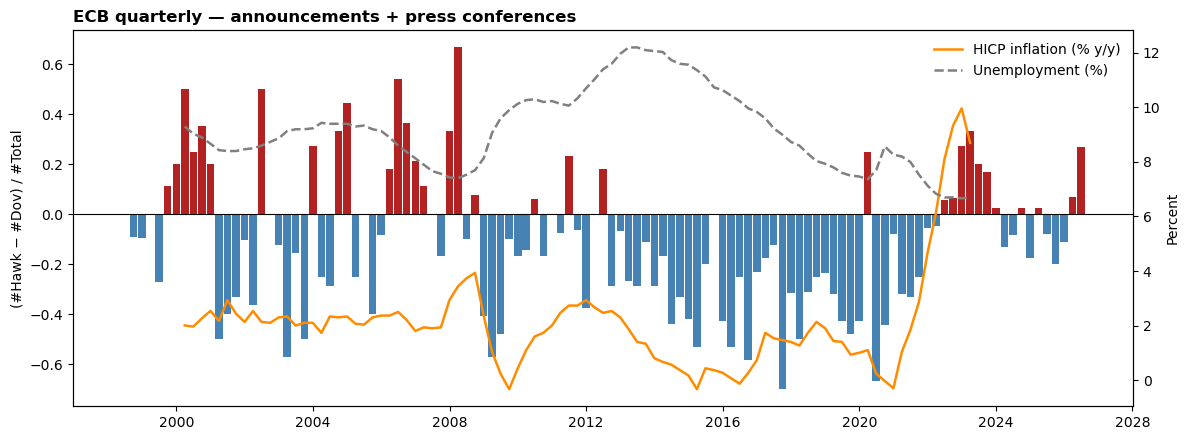

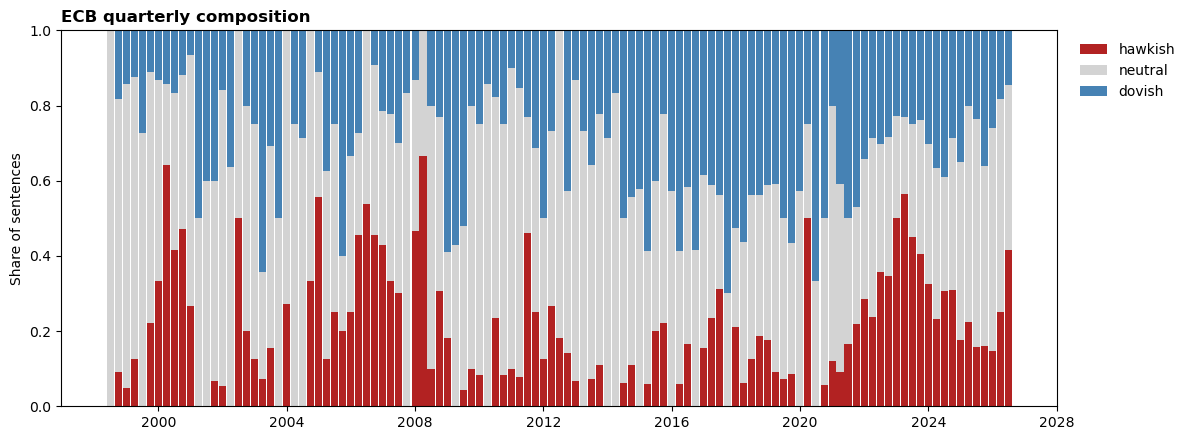

In [22]:
ea_ids = {
    "EA_HICP_YoY":  "EA19CPALTT01GYM",   # Euro area HICP, % change y/y, monthly
    "EA_Unemploy":  "LRHUTTTTEZM156S",   # Euro area harmonised unemployment rate, monthly
}
raw_ecb_macro = pd.concat(
    {name: fred_api_key.get_series(sid, observation_start=start_date, observation_end=end_date)
     for name, sid in ea_ids.items()},
    axis=1
)
ecb_macro = raw_ecb_macro.resample("ME").ffill()
ecb_macro
 
 
# %% [markdown]
# ### Diagnostic — check column names / label values before mapping
# (ECB files may not use the same column names or label codes as the FOMC ones)
 
# %%
for name, df in [("ECB announcements", ecb_announcment), ("ECB press conferences", ecb_pressconf)]:
    print(f"--- {name} ---")
    print("columns:", list(df.columns))
    print(df.head(3))
    print()
 
# %% [markdown]
# ### Fix these once the diagnostic output above tells you the real names
# (start from the FOMC clean_label — same H/D/N-with-M-prefix scheme is likely,
# but confirm against the printed label values first)
 
# %%
ECB_DATE_COL  = "date"    # <- update from diagnostic output
ECB_LABEL_COL = "label"   # <- update from diagnostic output
 
ecb_stmts = pd.DataFrame({
    "date":  pd.to_datetime(ecb_announcment[ECB_DATE_COL], errors="coerce"),
    "label": ecb_announcment[ECB_LABEL_COL].map(clean_label)
}).dropna()
 
ecb_pressc = pd.DataFrame({
    "date":  pd.to_datetime(ecb_pressconf[ECB_DATE_COL], errors="coerce"),
    "label": ecb_pressconf[ECB_LABEL_COL].map(clean_label)
}).dropna()

ecb_spch = pd.DataFrame({
    "date":  pd.to_datetime(ECB_speech[ECB_DATE_COL],errors="coerce"),
    "label": ECB_speech[ECB_LABEL_COL].map(clean_label)
}).dropna()

for name, df in [("ECB announcements", ecb_stmts), ("ECB press conferences", ecb_pressc), ("ECB speeches", ecb_spch)]:
    print(f"{name}: {len(df)} sentences  {df['label'].value_counts().to_dict()}")
 
# %% [markdown]
# ### Build the ECB index (quarterly only — no ECB speeches file given)
 
# %%
ecb_quarterly = build_index(pd.concat([ecb_stmts, ecb_pressc]), "QE")
ecb_macro_q = ecb_macro.resample("QE").mean().ffill()
 
# %%
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(ecb_quarterly.index, ecb_quarterly.values, width=80,
       color=["firebrick" if v >= 0 else "steelblue" for v in ecb_quarterly])
ax.axhline(0, color="black", lw=0.8)
ax.set_title("ECB quarterly — announcements + press conferences", loc="left", fontweight="bold")
ax.set_ylabel("(#Hawk − #Dov) / #Total")
 
axr = ax.twinx()
axr.plot(ecb_macro_q.index, ecb_macro_q["EA_HICP_YoY"], color="darkorange", lw=1.8, label="HICP inflation (% y/y)")
axr.plot(ecb_macro_q.index, ecb_macro_q["EA_Unemploy"], color="grey", ls="--", lw=1.8, label="Unemployment (%)")
axr.set_ylabel("Percent")
axr.legend(loc="upper right", frameon=False)
 
fig.tight_layout()
plt.show()
 
# %% [markdown]
# ### ECB composition chart
 
# %%
ecb_quarterly_comp = build_composition(pd.concat([ecb_stmts, ecb_pressc]), "QE")
 
fig, ax = plt.subplots(figsize=(12, 4.5))
bottom = pd.Series(0.0, index=ecb_quarterly_comp.index)
for label in ["hawkish", "neutral", "dovish"]:
    ax.bar(ecb_quarterly_comp.index, ecb_quarterly_comp[label], width=80, bottom=bottom,
           color=colors[label], label=label)
    bottom += ecb_quarterly_comp[label]
ax.set_title("ECB quarterly composition", loc="left", fontweight="bold")
ax.set_ylabel("Share of sentences")
ax.set_ylim(0, 1)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
fig.tight_layout()
plt.show()

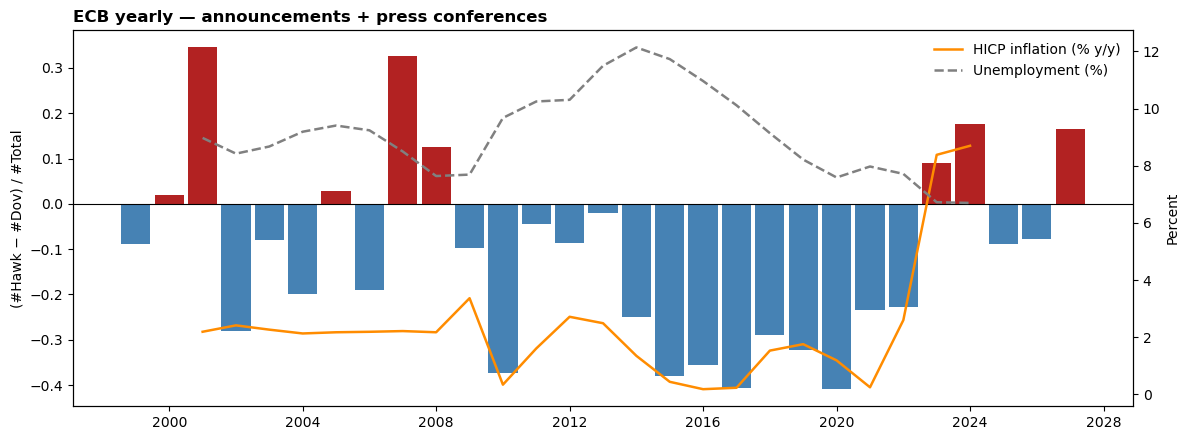

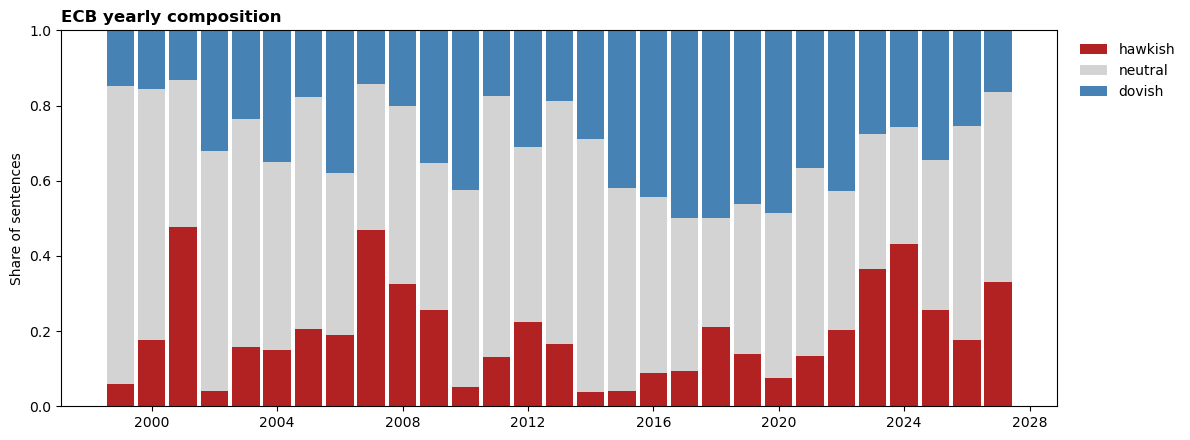

In [24]:
# %% [markdown]
# ### Build the ECB index — yearly frequency
# %%
ecb_yearly  = build_index(pd.concat([ecb_stmts, ecb_pressc]), "YE")
ecb_macro_y = ecb_macro.resample("YE").mean().ffill()
# %%
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(ecb_yearly.index, ecb_yearly.values, width=320,
       color=["firebrick" if v >= 0 else "steelblue" for v in ecb_yearly])
ax.axhline(0, color="black", lw=0.8)
ax.set_title("ECB yearly — announcements + press conferences", loc="left", fontweight="bold")
ax.set_ylabel("(#Hawk − #Dov) / #Total")
axr = ax.twinx()
axr.plot(ecb_macro_y.index, ecb_macro_y["EA_HICP_YoY"], color="darkorange", lw=1.8, label="HICP inflation (% y/y)")
axr.plot(ecb_macro_y.index, ecb_macro_y["EA_Unemploy"], color="grey", ls="--", lw=1.8, label="Unemployment (%)")
axr.set_ylabel("Percent")
axr.legend(loc="upper right", frameon=False)
fig.tight_layout()
plt.show()
# %% [markdown]
# ### ECB composition chart — yearly
# %%
ecb_yearly_comp = build_composition(pd.concat([ecb_stmts, ecb_pressc]), "YE")
fig, ax = plt.subplots(figsize=(12, 4.5))
bottom = pd.Series(0.0, index=ecb_yearly_comp.index)
for label in ["hawkish", "neutral", "dovish"]:
    ax.bar(ecb_yearly_comp.index, ecb_yearly_comp[label], width=320, bottom=bottom,
           color=colors[label], label=label)
    bottom += ecb_yearly_comp[label]
ax.set_title("ECB yearly composition", loc="left", fontweight="bold")
ax.set_ylabel("Share of sentences")
ax.set_ylim(0, 1)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
fig.tight_layout()
plt.show()

In [ ]:
ecb_pressconf.shape

(986, 5)

In [ ]:
ecb_announcment.shape

(1058, 10)

In [ ]:
fomc_announcment.shape

(1000, 8)

In [ ]:
fomc_pressconf.shape

(999, 9)

In [ ]:
fomc_speech.shape

(951, 6)

In [ ]:
# Quarterly source: statements + press conferences
fomc_quarterly_all = pd.concat([fomc_announcment, fomc_pressconf], ignore_index=True)

# Yearly source: statements + press conferences + speeches
fomc_yearly_all = pd.concat([fomc_announcment, fomc_pressconf, fomc_speech], ignore_index=True)

fomc_quarterly_all.to_csv("verification_quart.csv", index=False)
fomc_yearly_all.to_csv("verification_yearly.csv", index=False)

Claude Annotation Announcment

In [ ]:
# Claude Annotations File paths - For Announcments
Claude_Sonnet_Path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/LLM Annotation/Claude/FOMC Announcments")
Claude_Haiku_Path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/LLM Annotation/Claude/FOMC Announcments")
Claude_Opus_Path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/LLM Annotation/Claude/FOMC Announcments")
# Claude Announcments Dataframes
Claude_Sonnet_Announcment = pd.read_excel(Claude_Sonnet_Path/ "Claude Sonnet - FOMC Annoucment - .xlsx")
Claude_Haiku_Announcment = pd.read_csv(Claude_Haiku_Path / "Claude Haiku Fomc Annotations Annotations.csv")
Claude_Opus_Announcment = pd.read_csv(Claude_Opus_Path / "Claude Opus 5 Announcment Annotations .csv")
#Claude Annotation File Paths - For Press Conferences
Claude_Sonnet_Path_press = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/LLM Annotation/Claude/Press Conferences")
Claude_Haiku_Path_press = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/LLM Annotation/Claude/Press Conferences")
Claude_Opus_Path_press = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/LLM Annotation/Claude/Press Conferences")
# Claude Presconference Data Frames
Claude_Sonnet_press = pd.read_excel(Claude_Sonnet_Path_press/ "Sonnet_presconf_annotated_manual.xlsx")
Claude_Haiku_Announcment_press = pd.read_csv(Claude_Haiku_Path_press / "Haiku presconf_annotated_statements.csv")
Claude_Opus_Announcment_press = pd.read_excel(Claude_Opus_Path_press / "Opus presconf_annotated.xlsx")

Merging Dataframes

In [ ]:
# Claude FOMC announcement dataframes merge 

for name, df in [("statements", Claude_Sonnet_Announcment), ("press conferences", Claude_Sonnet_press)]:
    print(f"--- {name} ---")
    print("columns:", list(df.columns))
    print(df.head(3))
    print()

def clean_label_llm(x):
    """Accepts H/MH/D/MD/N codes, full words, and 0/1/2 numeric codes."""
    if pd.isna(x):
        return None
    s = str(x).strip().lower().rstrip(".")
    if "hawk" in s:                 return "hawkish"
    if "dov"  in s:                 return "dovish"
    if "neutral" in s:              return "neutral"
    if s in ("h", "mh"):            return "hawkish"
    if s in ("d", "md"):            return "dovish"
    if s == "n":                    return "neutral"
    if s in ("1", "1.0"):           return "hawkish"
    if s in ("0", "0.0"):           return "dovish"
    if s in ("2", "2.0"):           return "neutral"
    return None

docs_claude_sonnet = pd.concat([
    pd.DataFrame({
        "date":  pd.to_datetime(Claude_Sonnet_Announcment[DATE_COL], errors="coerce"),
        "label": Claude_Sonnet_Announcment[LABEL_COL].map(clean_label_llm)}),
    pd.DataFrame({
        "date":  pd.to_datetime(Claude_Sonnet_press[DATE_COL], errors="coerce"),
        "label": Claude_Sonnet_press[LABEL_COL].map(clean_label_llm)}),
], ignore_index=True)

bad_date  = docs_claude_sonnet["date"].isna().sum()
bad_label = docs_claude_sonnet["label"].isna().sum()
print(f"dropping {bad_date} bad dates, {bad_label} unmapped labels "
      f"of {len(docs_claude_sonnet)} rows")

docs_claude_sonnet = docs_claude_sonnet.dropna()
assert len(docs_claude_sonnet) > 0, "all rows dropped — check the diagnostic output"
print(docs_claude_sonnet["label"].value_counts().to_dict())

quarterly_claude_sonnet = build_index(docs_claude_sonnet, "QS")
yearly_claude_sonnet    = build_index(docs_claude_sonnet, "YS")
print("claude quarterly points:", quarterly_claude_sonnet.dropna().shape[0])
print("claude yearly points:",    yearly_claude_sonnet.dropna().shape[0])


--- statements ---
columns: ['id', 'raw_text', 'doc_type', 'clean_text', 'sentence', 'label', 'date', 'exact_match']
     id                                           raw_text   doc_type  \
0  2011  The Federal Open Market Committee at its meeti...  statement   
1  2009  The Federal Open Market Committee at its meeti...  statement   
2  2006  The Federal Open Market Committee at its meeti...  statement   

                                          clean_text  \
0  The Federal Open Market Committee at its meeti...   
1  The Federal Open Market Committee at its meeti...   
2  The Federal Open Market Committee at its meeti...   

                                            sentence    label       date  \
0  In these circumstances, and against the backgr...  Hawkish 2000-02-02   
1  Although core measures of prices are rising sl...  Neutral 2000-03-21   
2  Against the background of its long-term goals ...  Hawkish 2000-05-16   

   exact_match  
0        False  
1        False  
2        

In [ ]:
print(docs_claude_sonnet["label"].value_counts(dropna=False))
print(quarterly_claude_sonnet.head(10))
print("len:", len(quarterly_claude_sonnet),
      "all NaN:", quarterly_claude_sonnet.isna().all(),
      "index type:", type(quarterly_claude_sonnet.index))

label
neutral    1019
dovish      509
hawkish     470
Name: count, dtype: int64
date
2000-01-01    0.500000
2000-04-01    0.333333
2000-07-01    0.333333
2000-10-01    0.285714
2001-01-01    0.500000
2001-04-01    0.200000
2001-07-01    0.400000
2001-10-01    0.285714
2002-01-01    0.000000
2002-04-01    0.000000
Freq: QS-JAN, dtype: float64
len: 106 all NaN: False index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


Overlay on Human Annotated Samples

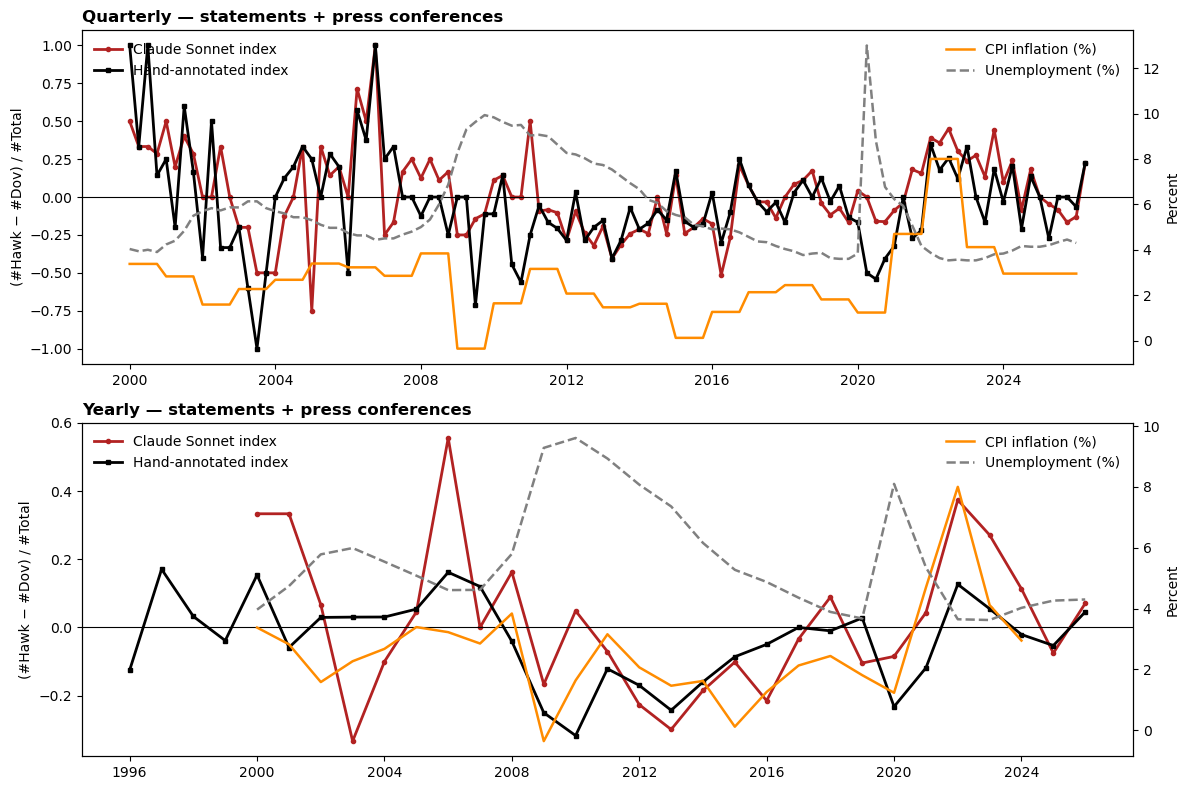

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

panels = [
    (axes[0], quarterly_claude_sonnet, quarterly, macro_q, "Quarterly — statements + press conferences"),
    (axes[1], yearly_claude_sonnet,    yearly,    macro_y, "Yearly — statements + press conferences"),
]

for ax, claude_idx, hand_idx, m, title in panels:
    ax.plot(claude_idx.index, claude_idx.values,
            color="firebrick", lw=2, marker="o", ms=3, label="Claude Sonnet index")
    ax.plot(hand_idx.index, hand_idx.values,
            color="black", lw=2, ls="-", marker="s", ms=3, label="Hand-annotated index")

    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel("(#Hawk − #Dov) / #Total")
    ax.legend(loc="upper left", frameon=False)

    axr = ax.twinx()
    axr.plot(m.index, m["US_Annual_CPI"], color="darkorange", lw=1.8, label="CPI inflation (%)")
    axr.plot(m.index, m["US_Unemploy"],   color="grey", ls="--", lw=1.8, label="Unemployment (%)")
    axr.set_ylabel("Percent")
    axr.legend(loc="upper right", frameon=False)

fig.tight_layout()
plt.show()

All Claude models and human annotation

Hand-annotated: 1996 sentences, 106 quarters, 2000-02-02 → 2026-06-17
Claude Sonnet: 1998 sentences, 106 quarters, 2000-02-02 → 2026-06-17
Claude Opus: 1998 sentences, 106 quarters, 2000-02-02 → 2026-06-17


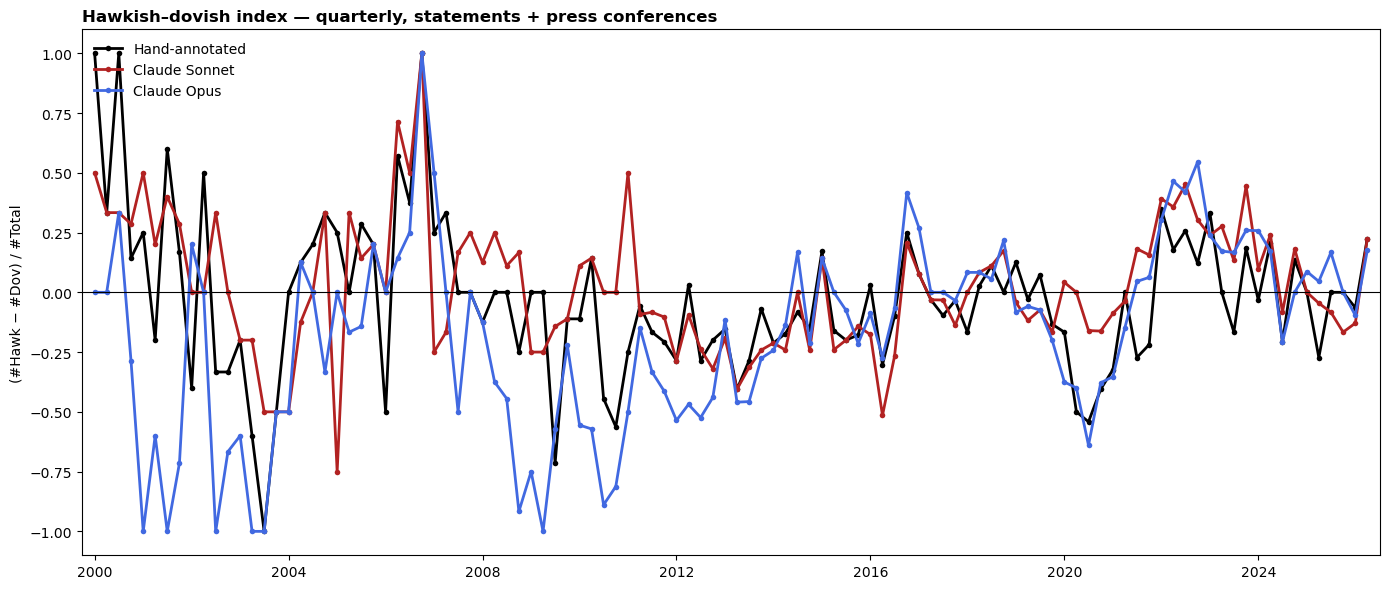

In [ ]:
# --- who we're comparing -------------------------------------------------
SOURCES = {
    "Hand-annotated": [fomc_announcment, fomc_pressconf],
    "Claude Sonnet":  [Claude_Sonnet_Announcment, Claude_Sonnet_press],
    "Claude Opus":    [Claude_Opus_Announcment, Claude_Opus_Announcment_press],
}

COLORS = {
    "Hand-annotated": "black",
    "Claude Sonnet":  "firebrick",
    "Claude Opus":    "royalblue",
}


# --- one file -> tidy (date, label) rows ---------------------------------
def to_docs(df):
    cols = {c.lower().strip(): c for c in df.columns}
    return pd.DataFrame({
        "date":  pd.to_datetime(df[cols["date"]], errors="coerce"),
        "label": df[cols["label"]].map(clean_label_llm),
    }).dropna()


# --- quarterly index -----------------------------------------------------
quarterly_idx = {}

for model, files in SOURCES.items():
    docs = pd.concat([to_docs(f) for f in files], ignore_index=True)
    quarterly_idx[model] = build_index(docs, "QS").dropna()

    print(f"{model}: {len(docs)} sentences, "
          f"{len(quarterly_idx[model])} quarters, "
          f"{docs['date'].min().date()} → {docs['date'].max().date()}")


# --- plot ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

for model, color in COLORS.items():
    s = quarterly_idx[model]
    ax.plot(s.index, s.values, color=color, lw=2, marker="o", ms=4,
            mec="none", label=model)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Hawkish–dovish index — quarterly, statements + press conferences",
             loc="left", fontweight="bold")
ax.set_ylabel("(#Hawk − #Dov) / #Total")
ax.legend(loc="upper left", frameon=False)
ax.margins(x=0.01)

fig.tight_layout()
plt.show()

Correlation heat map over time

106 quarters, 106 with all annotators present


/var/folders/k1/mhyzg0w15gb04d0x6q7gdp2w0000gn/T/ipykernel_79557/676440723.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


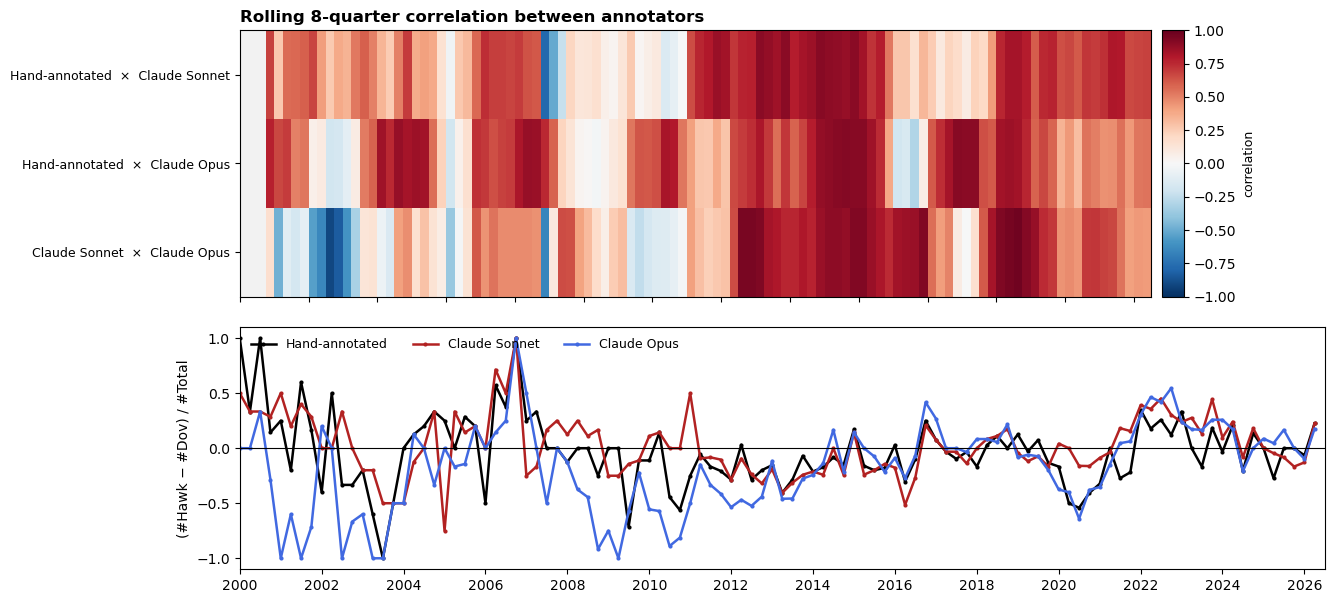

In [ ]:
import numpy as np
from itertools import combinations
import matplotlib.dates as mdates

WINDOW = 8   # quarters in each rolling window (2 years)

# --- align all annotators on one complete quarterly calendar -------------
aligned = pd.DataFrame(quarterly_idx).sort_index()
aligned = aligned.reindex(pd.date_range(aligned.index.min(),
                                        aligned.index.max(), freq="QS"))

# --- pairwise rolling correlation ---------------------------------------
pairs = list(combinations(aligned.columns, 2))
roll = pd.DataFrame({
    f"{a}  ×  {b}": aligned[a].rolling(WINDOW, min_periods=4).corr(aligned[b])
    for a, b in pairs
})

print(f"{len(aligned)} quarters, {aligned.notna().all(axis=1).sum()} with all annotators present")


# --- plot ----------------------------------------------------------------
fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(14, 7), height_ratios=[1.1, 1], sharex=True,
    gridspec_kw={"hspace": 0.12})

edges = pd.date_range(roll.index[0], periods=len(roll) + 1, freq="QS")
mesh = ax.pcolormesh(edges, np.arange(len(roll.columns) + 1),
                     np.ma.masked_invalid(roll.T.values),
                     cmap="RdBu_r", vmin=-1, vmax=1, shading="flat")

ax.set_yticks(np.arange(len(roll.columns)) + 0.5)
ax.set_yticklabels(roll.columns, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Rolling {WINDOW}-quarter correlation between annotators",
             loc="left", fontweight="bold")
ax.set_facecolor("#f2f2f2")          # empty windows show grey

cbar = fig.colorbar(mesh, ax=ax, pad=0.01, aspect=12)
cbar.set_label("correlation", fontsize=9)

# --- the underlying indices, for context ---------------------------------
for model, color in COLORS.items():
    ax2.plot(aligned.index, aligned[model], color=color, lw=1.8,
             marker="o", ms=3, mec="none", label=model)

ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("(#Hawk − #Dov) / #Total")
ax2.legend(loc="upper left", frameon=False, ncol=3, fontsize=9)
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()

Hand-annotated × Claude Sonnet: 103 windows, mean r = 0.49
Hand-annotated × Claude Opus: 103 windows, mean r = 0.53
Claude Sonnet × Claude Opus: 103 windows, mean r = 0.37


/var/folders/k1/mhyzg0w15gb04d0x6q7gdp2w0000gn/T/ipykernel_79557/200728819.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


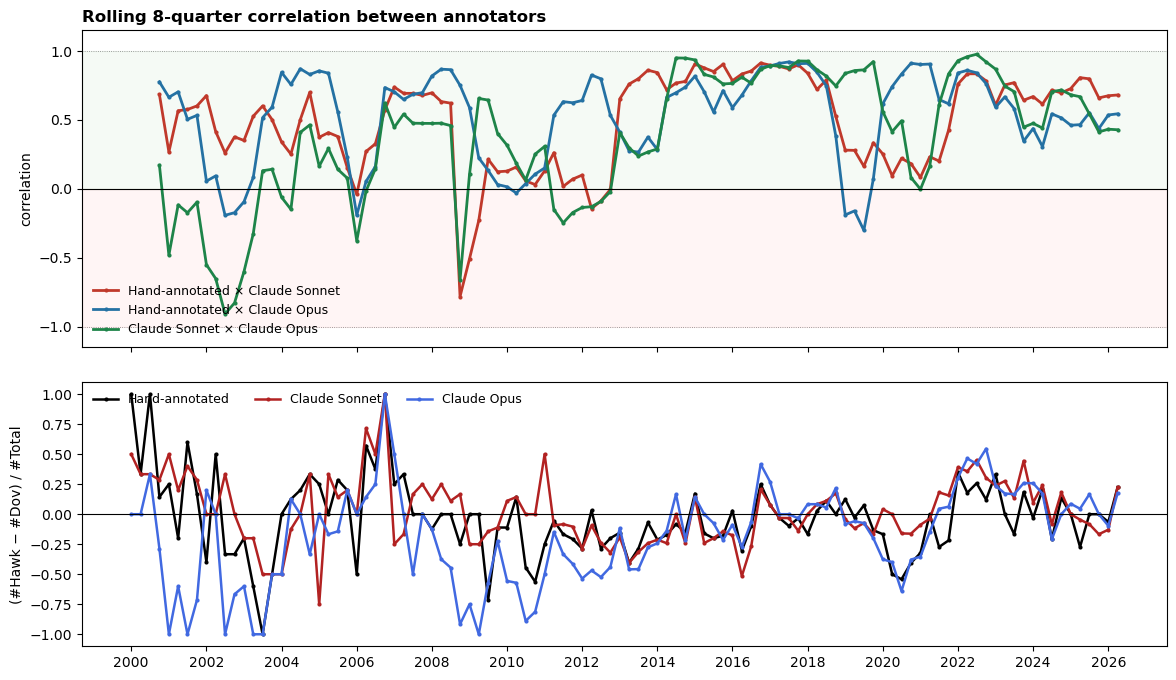

In [ ]:
import numpy as np
from itertools import combinations
import matplotlib.dates as mdates

WINDOW = 8   # quarters per window (2 years)

# --- align annotators on one complete quarterly calendar -----------------
aligned = pd.DataFrame(quarterly_idx).sort_index()
aligned = aligned.reindex(pd.date_range(aligned.index.min(),
                                        aligned.index.max(), freq="QS"))

# --- pairwise rolling correlation ---------------------------------------
pairs = list(combinations(aligned.columns, 2))
roll = pd.DataFrame({
    f"{a} × {b}": aligned[a].rolling(WINDOW, min_periods=4).corr(aligned[b])
    for a, b in pairs
})

PAIR_COLORS = dict(zip(roll.columns, ["#c0392b", "#2471a3", "#1e8449"]))

for col in roll.columns:
    print(f"{col}: {roll[col].notna().sum()} windows, mean r = {roll[col].mean():.2f}")


# --- plot ----------------------------------------------------------------
fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(14, 8), height_ratios=[1.2, 1], sharex=True,
    gridspec_kw={"hspace": 0.12})

ax.axhspan(0, 1, color="green", alpha=0.04)
ax.axhspan(-1, 0, color="red", alpha=0.04)

for col in roll.columns:
    ax.plot(roll.index, roll[col], color=PAIR_COLORS[col], lw=2,
            marker="o", ms=3, mec="none", label=col)

ax.axhline(0, color="black", lw=0.8)
ax.axhline(1, color="grey", lw=0.6, ls=":")
ax.axhline(-1, color="grey", lw=0.6, ls=":")
ax.set_ylim(-1.15, 1.15)
ax.set_ylabel("correlation")
ax.set_title(f"Rolling {WINDOW}-quarter correlation between annotators",
             loc="left", fontweight="bold")
ax.legend(loc="lower left", frameon=False, fontsize=9)

# --- underlying indices, for context ------------------------------------
for model, color in COLORS.items():
    ax2.plot(aligned.index, aligned[model], color=color, lw=1.8,
             marker="o", ms=3, mec="none", label=model)

ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("(#Hawk − #Dov) / #Total")
ax2.legend(loc="upper left", frameon=False, ncol=3, fontsize=9)
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()

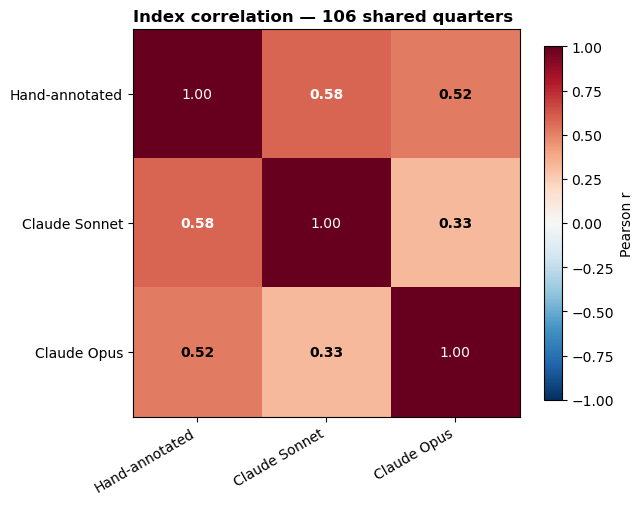

In [ ]:
import numpy as np

corr = aligned.dropna().corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr)), corr.columns, rotation=30, ha="right")
ax.set_yticks(range(len(corr)), corr.index)

for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.55 else "black",
                fontweight="bold" if i != j else "normal")

ax.set_title(f"Index correlation — {len(aligned.dropna())} shared quarters",
             loc="left", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
fig.tight_layout()
plt.show()

Correlation of Sentiment Indices with Unemployment and Inflation

105 quarters, 2000-01-01 → 2026-01-01


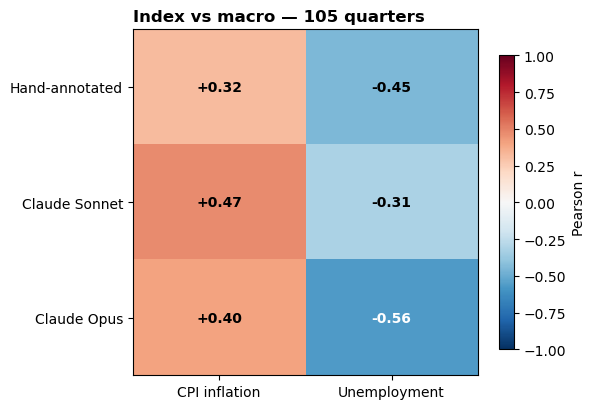

In [ ]:
# --- line up indices and macro on the same quarterly calendar ------------
MACRO_COLS = ["US_Annual_CPI", "US_Unemploy"]

panel = (pd.DataFrame(quarterly_idx)
           .join(macro_q[MACRO_COLS], how="inner")
           .dropna())

print(f"{len(panel)} quarters, {panel.index.min().date()} → {panel.index.max().date()}")

corr = panel.corr().loc[list(quarterly_idx), MACRO_COLS]

fig, ax = plt.subplots(figsize=(6, 4.2))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(MACRO_COLS)), ["CPI inflation", "Unemployment"])
ax.set_yticks(range(len(corr)), corr.index)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontweight="bold",
                color="white" if abs(v) > 0.55 else "black")

ax.set_title(f"Index vs macro — {len(panel)} quarters", loc="left", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.85, label="Pearson r")
fig.tight_layout()
plt.show()